## About Dataset

#### Context
- Simulated PayPal SMB (Small & Medium Business) customer base across 6 European markets (DE, FR, NL, IT, ES, UK).
- Business goal: predict which SMB merchant accounts are likely to become **dormant** (churn) in the next 90 days, so the Database Marketing team can hand a prioritized list to Sales for proactive retention.

#### Content
Each row represents one SMB merchant account. Columns describe:

- **Identity**: `account_id`, `country`, `industry`
- **Account maturity**: `account_age_months`
- **Transaction behavior**: `monthly_tpv` (Total Payment Volume), `tpv_trend_3m_pct`, `txn_count_monthly`, `avg_ticket_size`
- **Product adoption**: `num_products_used` (Checkout, Invoicing, POS, BNPL)
- **Engagement**: `login_freq_monthly`
- **Friction signals**: `disputes_90d`, `chargebacks_90d`, `support_tickets_90d`, `failed_txn_ratio`
- **Target**: `churn` (1 = became dormant in next 90 days)


## Exploration & Data loading

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('whitegrid')

In [3]:
import sys
print(sys.executable)

d:\PayPal-SMB-EU-Churn-ML\PayPal-SMB-EU-Churn-ML\.venv\Scripts\python.exe


In [4]:
df = pd.read_csv(r'D:\PayPal-SMB-EU-Churn-ML\PayPal-SMB-EU-Churn-ML\paypal_smb_eu_churn.csv')
df.shape

(6000, 15)

In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
df.head()

,account_id,country,industry,account_age_months,monthly_tpv,tpv_trend_3m_pct,txn_count_monthly,avg_ticket_size,num_products_used,login_freq_monthly,disputes_90d,chargebacks_90d,support_tickets_90d,failed_txn_ratio,churn
0,SMB_EU_000001,FR,Hospitality,16,2985.90,-22.65,11,271.45,3,9,1,0,1,0.121,0
1,SMB_EU_000002,UK,Retail,31,2313.88,-16.33,20,115.69,4,7,2,0,1,0.205,0
2,SMB_EU_000003,ES,Services,44,1237.23,-14.85,9,137.47,4,10,1,0,1,0.040,0
3,SMB_EU_000004,IT,Hospitality,27,9526.22,-26.94,66,144.34,2,10,0,1,0,0.184,0
4,SMB_EU_000005,DE,Retail,34,5518.22,16.27,37,149.14,1,12,2,2,0,0.199,0


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
account_id,6000,6000,SMB_EU_000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,6000,6,DE,1342,NaN,NaN,NaN,NaN,NaN,NaN,NaN
industry,6000,5,E-commerce,1882,NaN,NaN,NaN,NaN,NaN,NaN,NaN
account_age_months,6000.0,NaN,NaN,NaN,31.103167,20.403478,1.0,16.0,27.0,42.0,120.0
monthly_tpv,6000.0,NaN,NaN,NaN,11170.18788,8980.623571,692.19,5217.88,8398.12,14146.0325,88417.08
tpv_trend_3m_pct,6000.0,NaN,NaN,NaN,-7.67711,22.34227,-106.41,-18.755,-4.41,7.7425,55.37
txn_count_monthly,6000.0,NaN,NaN,NaN,66.904167,63.784434,3.0,27.0,48.0,83.0,841.0
avg_ticket_size,6000.0,NaN,NaN,NaN,189.955718,63.172023,79.09,135.7175,190.83,243.26,314.87
num_products_used,6000.0,NaN,NaN,NaN,2.135,1.033418,1.0,1.0,2.0,3.0,4.0
login_freq_monthly,6000.0,NaN,NaN,NaN,10.057,3.134654,2.0,8.0,10.0,12.0,24.0


**Observations (vs Telco dataset):**
- No missing values (simulated cleanly) — unlike Telco's `TotalCharges` which had blank strings.
- `country` and `industry` are the only categorical columns — both **nominal** (no natural order), so both need **One-Hot Encoding**. There are no Yes/No binary columns like Telco had (`Partner`, `Dependents`, etc.), so the **Binary Encoding** step from the Telco notebook is not needed here.
- Target `churn` is already 0/1.


## Target Distribution — Class Imbalance Check

Churn rate: 11.67%


C:\Users\pradh\AppData\Local\Temp\ipykernel_42184\3852066823.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette=['#0070BA','#FF5C5C'])


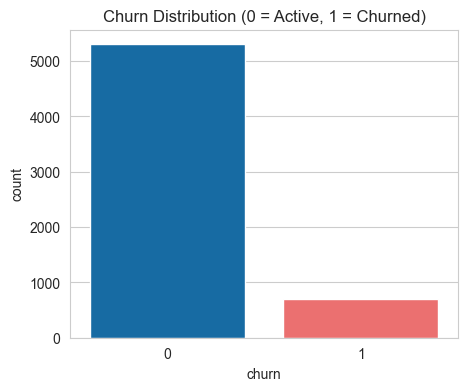

In [7]:
churn_rate = df['churn'].mean()
print(f"Churn rate: {churn_rate:.2%}")

plt.figure(figsize=(5,4))
sns.countplot(x='churn', data=df, palette=['#0070BA','#FF5C5C'])
plt.title('Churn Distribution (0 = Active, 1 = Churned)')
plt.show()

Same imbalance pattern as Telco (~26% there vs ~12% here) — confirms we'll need `scale_pos_weight` / class-weighting again for tree models.

## Categorical Feature Exploration

C:\Users\pradh\AppData\Local\Temp\ipykernel_42184\1610749338.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='country', y='churn', data=df, ax=axes[0], palette='Blues_d')
C:\Users\pradh\AppData\Local\Temp\ipykernel_42184\1610749338.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='industry', y='churn', data=df, ax=axes[1], palette='Oranges_d')


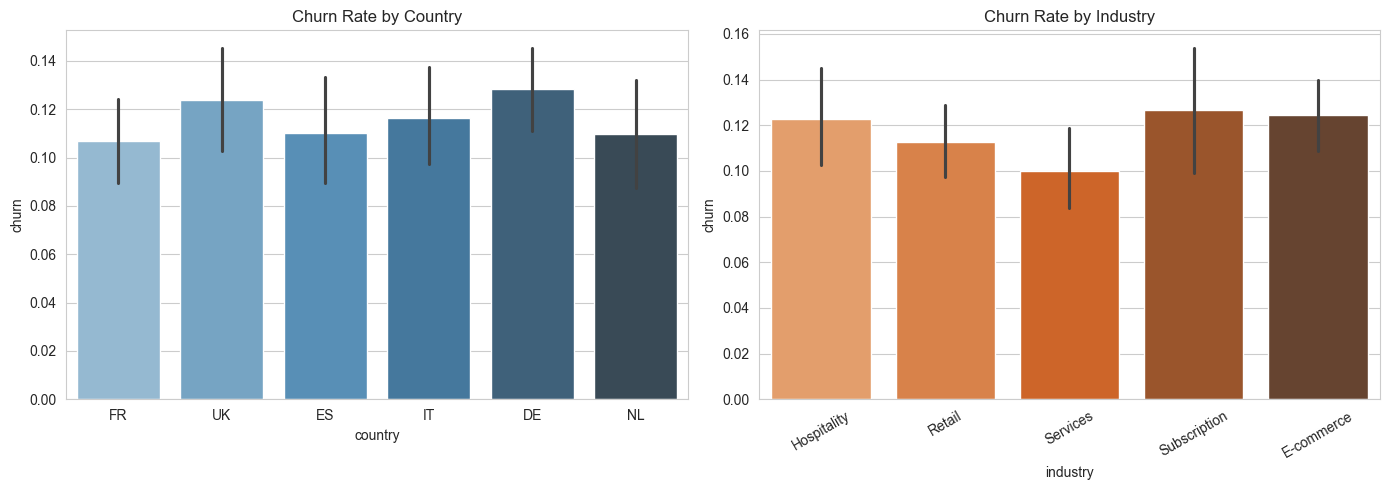

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(x='country', y='churn', data=df, ax=axes[0], palette='Blues_d')
axes[0].set_title('Churn Rate by Country')
sns.barplot(x='industry', y='churn', data=df, ax=axes[1], palette='Oranges_d')
axes[1].set_title('Churn Rate by Industry')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

Since this data is simulated without a country/industry effect baked in, churn rates should look roughly flat across groups — a real dataset would likely show Stripe-competitive markets (e.g. UK, DE) with higher churn.

## Numeric Feature Distributions by Churn

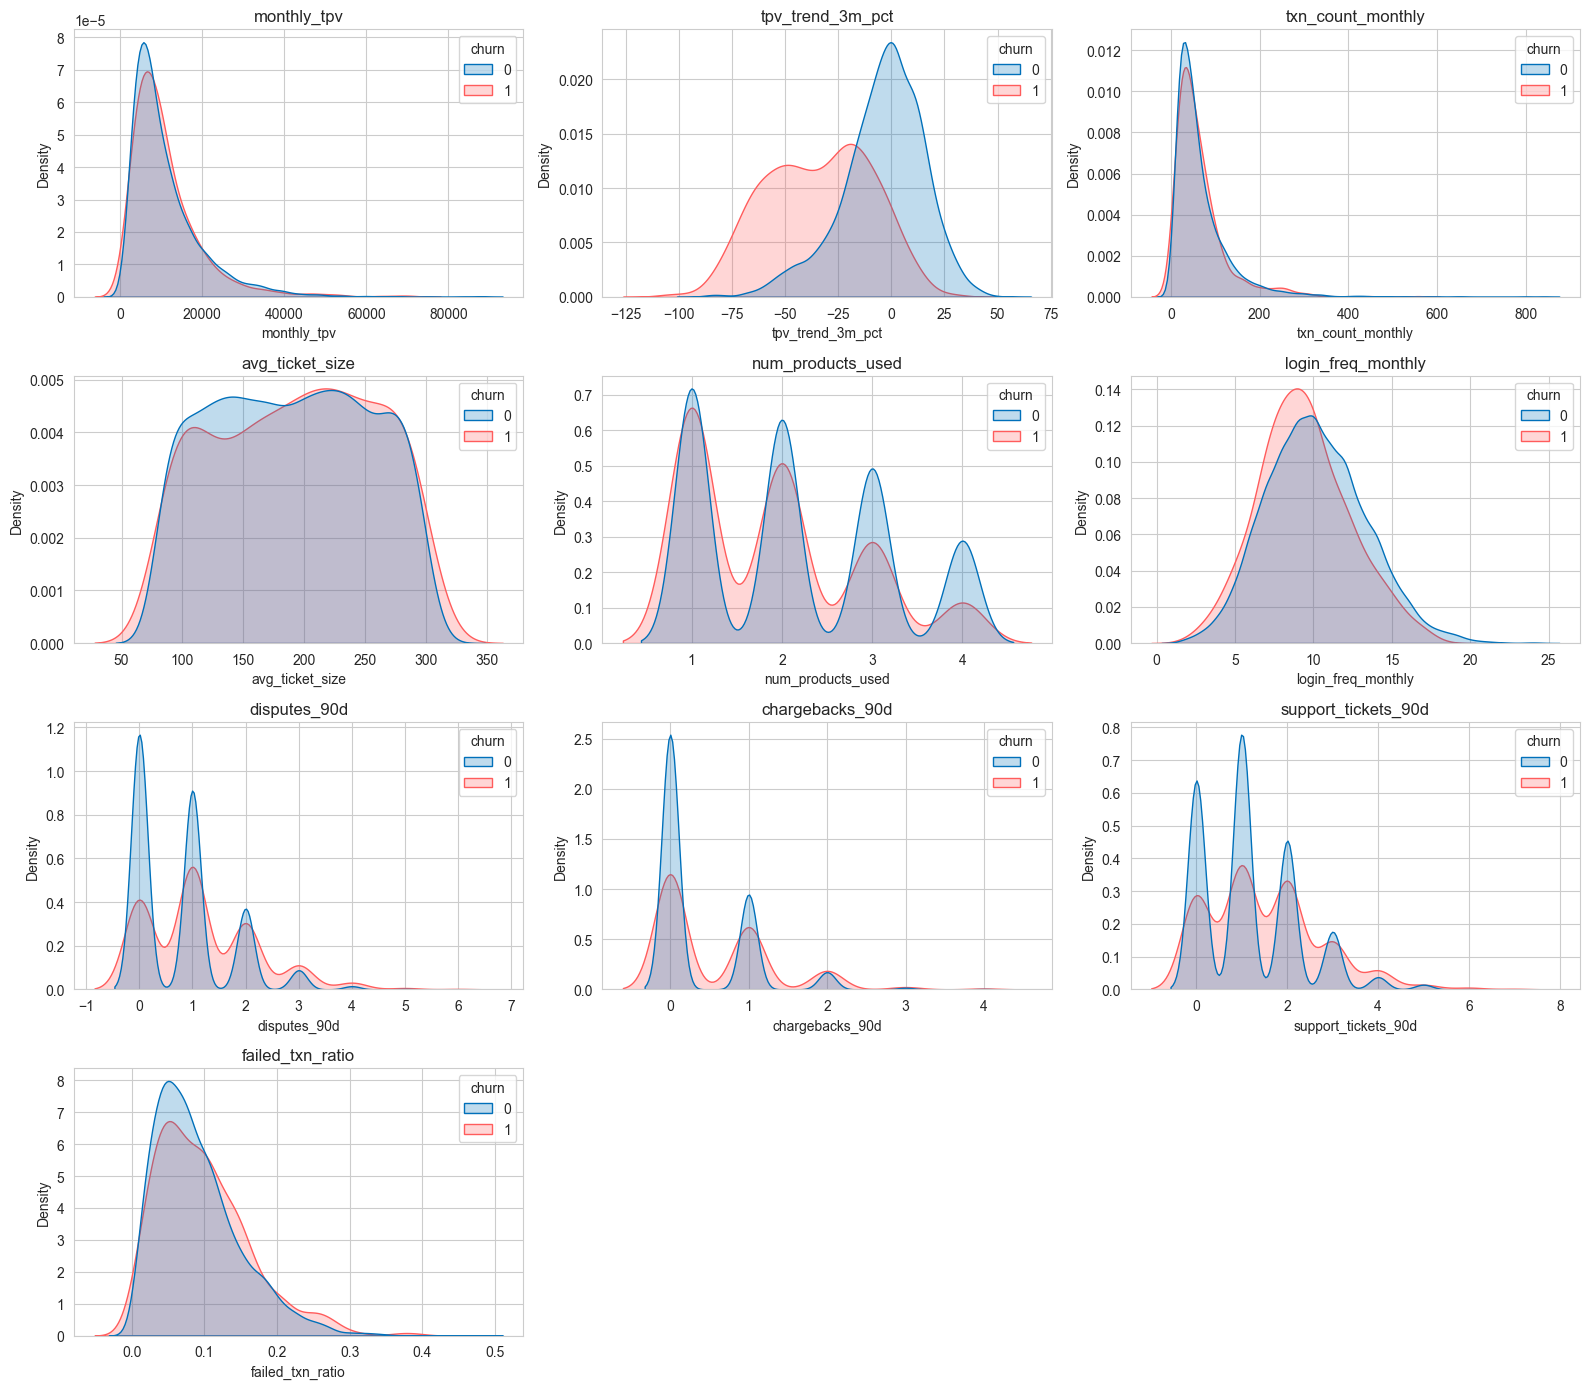

In [9]:
numeric_cols = ['monthly_tpv','tpv_trend_3m_pct','txn_count_monthly','avg_ticket_size',
                'num_products_used','login_freq_monthly','disputes_90d','chargebacks_90d',
                'support_tickets_90d','failed_txn_ratio']

fig, axes = plt.subplots(4, 3, figsize=(16,14))
axes = axes.flatten()
for i, colname in enumerate(numeric_cols):
    sns.kdeplot(data=df, x=colname, hue='churn', fill=True, common_norm=False, ax=axes[i], palette=['#0070BA','#FF5C5C'])
    axes[i].set_title(colname)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

**Expected pattern (by design of the simulation):**
- `tpv_trend_3m_pct` should be **shifted left (more negative)** for churners — declining volume is the strongest engineered churn driver.
- `disputes_90d`, `chargebacks_90d`, `support_tickets_90d`, `failed_txn_ratio` should be **shifted right (higher)** for churners.
- `login_freq_monthly` and `num_products_used` should be **shifted left** for churners (less engaged, fewer products = less sticky).


## One-Hot Encoding

Both `country` and `industry` are nominal categorical columns with more than 2 unique values — same treatment as Telco's `InternetService`, `Contract`, `PaymentMethod`, etc.

In [10]:
df_encoded = pd.get_dummies(df, columns=['country','industry'], drop_first=True)
df_encoded.head()

,account_id,account_age_months,monthly_tpv,tpv_trend_3m_pct,txn_count_monthly,avg_ticket_size,num_products_used,login_freq_monthly,disputes_90d,chargebacks_90d,support_tickets_90d,failed_txn_ratio,churn,country_ES,country_FR,country_IT,country_NL,country_UK,industry_Hospitality,industry_Retail,industry_Services,industry_Subscription
0,SMB_EU_000001,16,2985.90,-22.65,11,271.45,3,9,1,0,1,0.121,0,False,True,False,False,False,True,False,False,False
1,SMB_EU_000002,31,2313.88,-16.33,20,115.69,4,7,2,0,1,0.205,0,False,False,False,False,True,False,True,False,False
2,SMB_EU_000003,44,1237.23,-14.85,9,137.47,4,10,1,0,1,0.040,0,True,False,False,False,False,False,False,True,False
3,SMB_EU_000004,27,9526.22,-26.94,66,144.34,2,10,0,1,0,0.184,0,False,False,True,False,False,True,False,False,False
4,SMB_EU_000005,34,5518.22,16.27,37,149.14,1,12,2,2,0,0.199,0,False,False,False,False,False,False,True,False,False


## Cleaning

In [11]:
df_encoded = df_encoded.drop('account_id', axis=1)  # identifier, not a feature
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   account_age_months     6000 non-null   int64  
 1   monthly_tpv            6000 non-null   float64
 2   tpv_trend_3m_pct       6000 non-null   float64
 3   txn_count_monthly      6000 non-null   int64  
 4   avg_ticket_size        6000 non-null   float64
 5   num_products_used      6000 non-null   int64  
 6   login_freq_monthly     6000 non-null   int64  
 7   disputes_90d           6000 non-null   int64  
 8   chargebacks_90d        6000 non-null   int64  
 9   support_tickets_90d    6000 non-null   int64  
 10  failed_txn_ratio       6000 non-null   float64
 11  churn                  6000 non-null   int64  
 12  country_ES             6000 non-null   bool   
 13  country_FR             6000 non-null   bool   
 14  country_IT             6000 non-null   bool   
 15  coun

## Correlation with Target

In [12]:
corr_matrix = df_encoded.corr(numeric_only=True)
corr_matrix['churn'].sort_values(ascending=False)

churn                    1.000000
disputes_90d             0.139804
support_tickets_90d      0.096889
chargebacks_90d          0.093953
failed_txn_ratio         0.043001
avg_ticket_size          0.017780
industry_Subscription    0.010064
country_UK               0.009729
industry_Hospitality     0.007620
country_IT              -0.000348
monthly_tpv             -0.003170
industry_Retail         -0.006963
country_NL              -0.007618
country_ES              -0.008087
txn_count_monthly       -0.008766
country_FR              -0.015472
industry_Services       -0.025552
account_age_months      -0.066525
login_freq_monthly      -0.077336
num_products_used       -0.081142
tpv_trend_3m_pct        -0.432611
Name: churn, dtype: float64

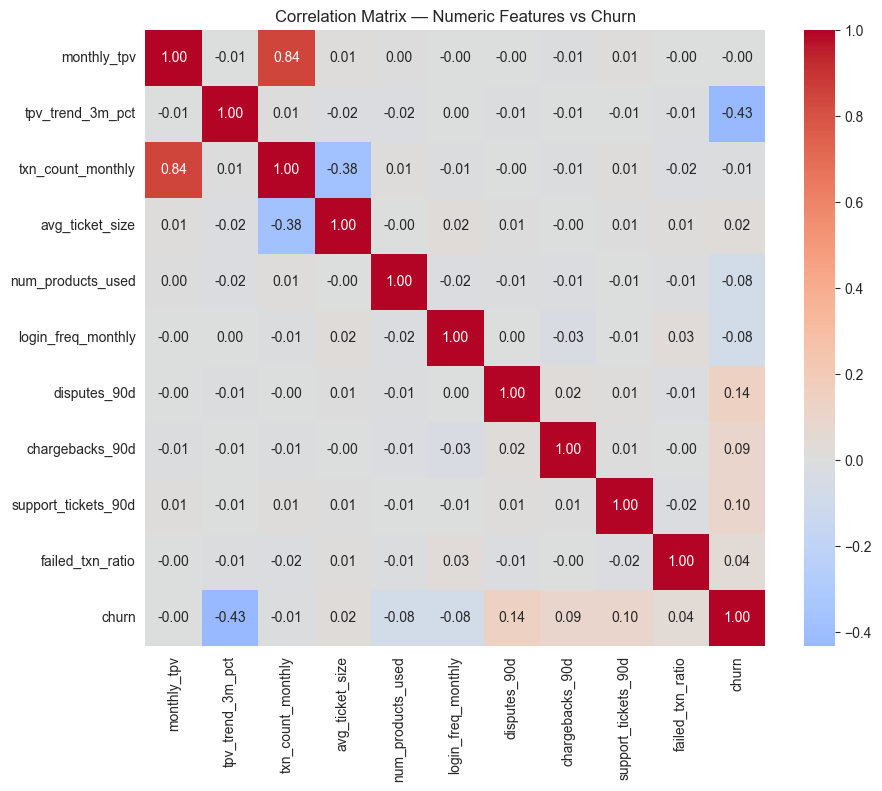

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded[numeric_cols + ['churn']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Numeric Features vs Churn')
plt.show()

**Positive correlation with churn (higher value → more likely to churn):**
`disputes_90d`, `chargebacks_90d`, `support_tickets_90d`, `failed_txn_ratio`

**Negative correlation (lower value → more likely to churn):**
`tpv_trend_3m_pct`, `login_freq_monthly`, `num_products_used`, `account_age_months`

This matches the business logic we designed the simulation around — a good sanity check that the synthetic data behaves realistically before we hand it to a model.


## Look for Multicollinearity (VIF)

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Prepare predictor matrix: drop target and cast to numeric floats
X_vif = df_encoded.drop('churn', axis=1).astype(float)

# 2. Compute VIF for all features
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i) 
    for i in range(len(X_vif.columns))
]

# 3. Sort features by collinearity
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
display(vif_data)

,feature,VIF
0,txn_count_monthly,7.501740
1,monthly_tpv,6.781605
2,avg_ticket_size,2.151275
3,industry_Services,1.700664
4,industry_Retail,1.585062
5,country_FR,1.524789
6,industry_Hospitality,1.482806
7,country_IT,1.458802
8,country_UK,1.434961
9,country_ES,1.396134


`monthly_tpv`, `txn_count_monthly`, and `avg_ticket_size` are mathematically related (`avg_ticket_size = monthly_tpv / txn_count_monthly`), so expect elevated VIF there — same type of redundancy Telco had between `tenure`/`TotalCharges`/`MonthlyCharges`. Tree-based models (RF/LightGBM/XGBoost) are robust to this, so we won't drop features yet, but we'd revisit this if we later use Logistic Regression.

## Machine Learning

In [15]:
# Class imbalance — same issue as Telco
df_encoded['churn'].value_counts(normalize=True)

churn
0    0.883333
1    0.116667
Name: proportion, dtype: float64

In SMB churn prediction, **recall** (catching actual churners) generally matters more than raw accuracy — missing a churner means losing the account entirely. But because Sales has **limited outreach bandwidth**, precision can't be ignored either (unlike a pure "contact everyone" strategy). We'll track Precision, Recall, F1, and ROC-AUC together, same as the Telco project.

**Typical priority:** Recall ≥ Precision, but F1/ROC-AUC guard against a model that just flags everyone.


In [16]:
import sys
print(sys.executable)

d:\PayPal-SMB-EU-Churn-ML\PayPal-SMB-EU-Churn-ML\.venv\Scripts\python.exe


In [17]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train.shape, X_test.shape

((4800, 20), (1200, 20))

### RandomForest Classifier

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred, digits=3))

              precision    recall  f1-score   support

           0      0.897     0.991     0.941      1060
           1      0.655     0.136     0.225       140

    accuracy                          0.891      1200
   macro avg      0.776     0.563     0.583      1200
weighted avg      0.868     0.891     0.858      1200



### LightGBM Classifier

In [19]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(class_weight='balanced', random_state=42, verbosity=-1)
lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)

print(classification_report(y_test, lgbm_pred, digits=3))

              precision    recall  f1-score   support

           0      0.931     0.910     0.921      1060
           1      0.421     0.493     0.454       140

    accuracy                          0.862      1200
   macro avg      0.676     0.702     0.687      1200
weighted avg      0.872     0.862     0.866      1200



### XGBoost Classifier

In [20]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42,
                          eval_metric='logloss', n_jobs=-1)
xgb_base.fit(X_train, y_train)
xgb_pred = xgb_base.predict(X_test)

print(classification_report(y_test, xgb_pred, digits=3))

              precision    recall  f1-score   support

           0      0.916     0.948     0.932      1060
           1      0.466     0.343     0.395       140

    accuracy                          0.877      1200
   macro avg      0.691     0.645     0.663      1200
weighted avg      0.864     0.877     0.869      1200



### ML model choice: XGBoost — chosen for the same reasons as the Telco project: handles imbalance natively via `scale_pos_weight`, robust to multicollinearity/mixed feature scales, and gives us feature importances for the Sales/Marketing narrative.

## Hyperparameter Tuning (Optuna) & Experiment Tracking (MLflow)

In [21]:
import optuna
from sklearn.metrics import recall_score

THRESHOLD = 0.5

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'scale_pos_weight': (y_train == 0).sum() / (y_train == 1).sum(),
        'eval_metric': 'logloss'
    }
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    return recall_score(y_test, y_pred, pos_label=1)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15)

print('Best Params:', study.best_params)
print('Best Recall:', study.best_value)

Best Params: {'max_depth': 3, 'learning_rate': 0.010280984932078343, 'n_estimators': 303, 'subsample': 0.7777856409580004, 'colsample_bytree': 0.7124567726561332}
Best Recall: 0.7571428571428571


In [22]:
import mlflow
import mlflow.xgboost
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import time, os

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('PayPal SMB EU Churn - XGBoost')

with mlflow.start_run():
    best_params = study.best_params
    best_params.update({
        'random_state': 42, 'n_jobs': -1,
        'scale_pos_weight': (y_train == 0).sum() / (y_train == 1).sum(),
        'eval_metric': 'logloss'
    })
    mlflow.log_params(best_params)

    start = time.time()
    xgb_tuned = XGBClassifier(**best_params)
    xgb_tuned.fit(X_train, y_train)
    mlflow.log_metric('train_time', time.time() - start)

    proba = xgb_tuned.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, proba)

    mlflow.log_metric('precision', precision)
    mlflow.log_metric('recall', recall)
    mlflow.log_metric('f1', f1)
    mlflow.log_metric('roc_auc', auc)
    mlflow.xgboost.log_model(xgb_tuned, 'model')

    print(classification_report(y_test, y_pred, digits=3))
    print(f'ROC-AUC: {auc:.3f}')

2026/09/07 01:02:59 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/07 01:02:59 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
INFO  [alembic.runtime.migration] Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
INFO  [alembic.runtime.migration] Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
INFO  [alembic.runtime.migration] Running upgrade 7ac759974ad8 -> 89d4b8295536, create latest metrics table
INFO  [89d4b8295536_create_latest_metrics_table_py] Migration complete!
INFO  

              precision    recall  f1-score   support

           0      0.962     0.807     0.877      1060
           1      0.341     0.757     0.470       140

    accuracy                          0.801      1200
   macro avg      0.651     0.782     0.674      1200
weighted avg      0.889     0.801     0.830      1200

ROC-AUC: 0.859


### Feature Importance — the story for Sales/Marketing

C:\Users\pradh\AppData\Local\Temp\ipykernel_42184\981195605.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values[:10], y=importances.index[:10], palette='viridis')


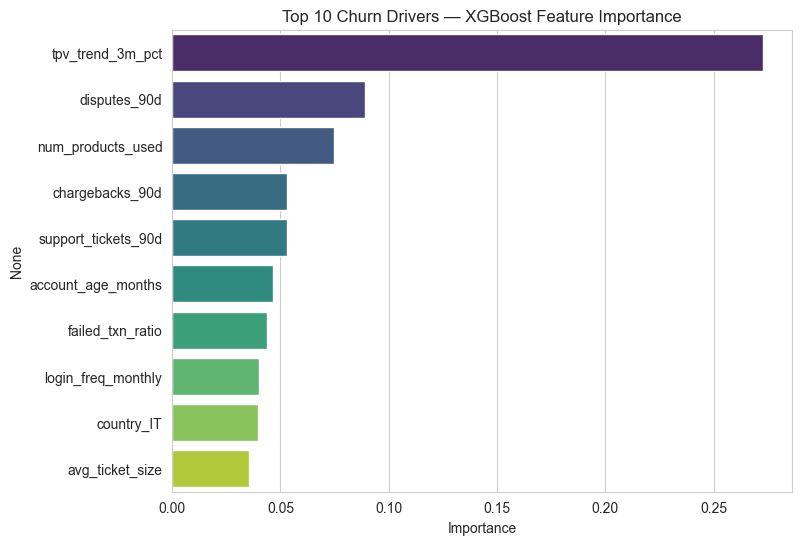

tpv_trend_3m_pct       0.272586
disputes_90d           0.089118
num_products_used      0.074855
chargebacks_90d        0.052846
support_tickets_90d    0.052812
account_age_months     0.046630
failed_txn_ratio       0.044012
login_freq_monthly     0.039919
country_IT             0.039470
avg_ticket_size        0.035597
dtype: float32

In [23]:
importances = pd.Series(xgb_tuned.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=importances.values[:10], y=importances.index[:10], palette='viridis')
plt.title('Top 10 Churn Drivers — XGBoost Feature Importance')
plt.xlabel('Importance')
plt.show()
importances.head(10)

**Interpretation:** whichever features top this list become the retention-team narrative — e.g. *"declining transaction volume over 3 months is the #1 churn signal, followed by dispute rate."* This is exactly the kind of explainability output the Database Marketing team hands to Sales to justify why an account is on the at-risk list.